In [ ]:
import nugget
import numpy as np
import importlib

In [29]:
importlib.reload(nugget.utils.vis_tools)
importlib.reload(nugget.losses.geometry_penalties)
geometry = nugget.geometries.EvanescentString.EvanescentString(
            hex_type='hexagonal',
            domain_size=1600,  # Size of detector domain
            dim=3,  # 3D geometry
            n_strings=1000,  # Initial number of detector strings
            points_per_string=20,  # Number of PMTs/sensors per string
            custom_z_spacing=50,
            starting_weight =1000
        )

visualizer = nugget.utils.vis_tools.Visualizer(
    # device=geometry.device,
    dim=3, 
    domain_size=1600,
    )

evaluator = nugget.utils.basic_evaluator.Evaluator(
    geometry=geometry,
    visualizer=visualizer,
)

In [33]:
rov_penalty = nugget.losses.geometry_penalties.ROVPenalty(
    device=geometry.device, 
    rov_rec_width=230,  # ROV dimensions
    rov_height=159.9, 
    rov_tri_length=159.9
)

loss_params ={
    'num_angles': 360,  # Number of angles (divided into 360 degrees) to test for rov
}

loss_func_dict = {
    'rov_penalty': rov_penalty,
}

plot_types = [
    # 'string_xy',
    'string_xy_rov_penalty',
]

vis_kwargs = {
    'plot_types': plot_types,
    # 'zoom_range':800,
    'rov_penalty_func': rov_penalty,
    'rov_draw_safe_space_on_violations':False
}

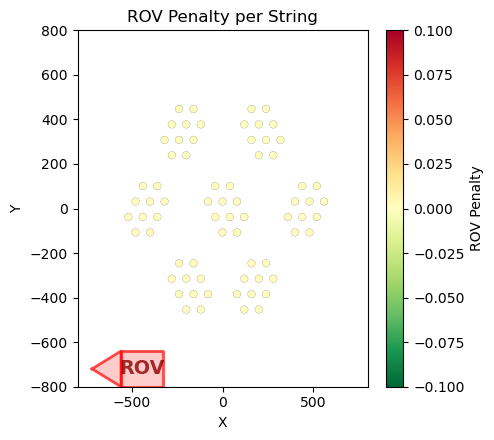

Eval | rov_penalty: -0.0370731


In [36]:
result =evaluator.evaluate(
    geom_dict={'string_xy': np.load('/u/kristiantcho/ptmp/other/default_xy.npy')},
    loss_func_dict=loss_func_dict,
    loss_params_dict=loss_params,
    vis_kwargs=vis_kwargs,
    visualize=True,
)